In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import fastparquet

In [2]:
data=pd.read_csv("../../Bronze/raw_data.csv")

In [3]:
data

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


In [4]:
data['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

In [5]:
data.nunique()

userid            90189
version               2
sum_gamerounds      942
retention_1           2
retention_7           2
dtype: int64

In [6]:
data.dtypes

userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

la colonne version correspond à la version , or elle n a que 2 version , 30 et 40 , donc on modifiera le type qui est objet pour le mettre en int . 

In [7]:
data.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Donc aucun doublons 

In [8]:
dict={"gate_30":30,"gate_40":40}

In [9]:
data['version']=data['version'].map(dict)

In [10]:
data

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,30,3,False,False
1,337,30,38,True,False
2,377,40,165,True,False
3,483,40,1,False,False
4,488,40,179,True,True
...,...,...,...,...,...
90184,9999441,40,97,True,False
90185,9999479,40,30,False,False
90186,9999710,30,28,True,False
90187,9999768,40,51,True,False


In [11]:
data=data.drop('userid',axis=1)

on peut supprimer la colonne userid car inutile 


In [12]:
data

,version,sum_gamerounds,retention_1,retention_7
0,30,3,False,False
1,30,38,True,False
2,40,165,True,False
3,40,1,False,False
4,40,179,True,True
...,...,...,...,...
90184,40,97,True,False
90185,40,30,False,False
90186,30,28,True,False
90187,40,51,True,False


In [13]:
data[data['sum_gamerounds']>300]

,version,sum_gamerounds,retention_1,retention_7
14,30,305,True,True
45,30,386,True,True
237,40,493,True,True
275,30,391,True,False
320,30,467,True,True
...,...,...,...,...
89971,30,341,True,True
90017,30,438,True,True
90030,40,317,True,True
90115,40,569,True,True


In [14]:
data["sum_gamerounds"].max()

np.int64(49854)

Puisque notre problème est la rétention de joueurs , on peut estimer qu a partir d un certain nombre de parties, le joueur est considéré comme acquis . donc on se concentrerat sur les joueurs ayant moins de 100 parties 

(array([21725., 20601.,  6443.,  8151., 10104.,  6731.,  4049.]),
 array([  0.,   5.,  15.,  20.,  30.,  50.,  75., 100.]),
 <BarContainer object of 7 artists>)

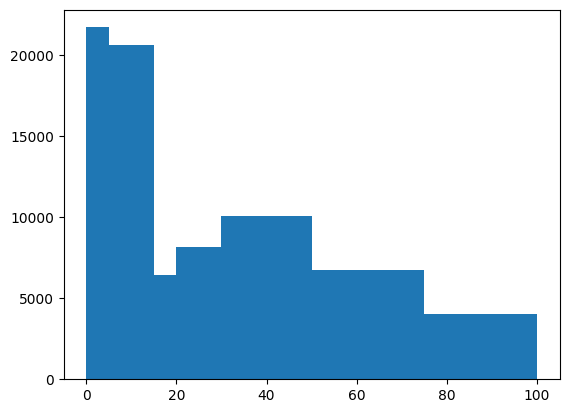

In [15]:
plt.hist(data["sum_gamerounds"],bins=[0,5,15,20,30,50,75,100])

In [16]:
data=data[data["sum_gamerounds"]<100]

On va créer une nouvelle colonne "segment activite " qui permet de diviser chaque joueur en fonction de son nombre de partie , entre low pour des joueurs ayant jouer peu de parties , medium pour moyen et high pour les autres .

In [17]:
indices_low=data.index[data["sum_gamerounds"]< 5]
indices_medium=data.index[(data["sum_gamerounds"]>5) & (data["sum_gamerounds"]<50) ]
indices_high=data.index[data["sum_gamerounds"]>50]

In [18]:
data.loc[indices_low, "segment_activite"]="low"
data.loc[indices_medium, "segment_activite"]="medium"
data.loc[indices_high, "segment_activite"]="high"

C:\Users\galva\AppData\Local\Temp\ipykernel_5700\4253030948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[indices_low, "segment_activite"]="low"


In [19]:
data

,version,sum_gamerounds,retention_1,retention_7,segment_activite
0,30,3,False,False,low
1,30,38,True,False,medium
3,40,1,False,False,low
6,30,0,False,False,low
7,40,2,False,False,low
...,...,...,...,...,...
90184,40,97,True,False,high
90185,40,30,False,False,medium
90186,30,28,True,False,medium
90187,40,51,True,False,high


In [20]:
indices_false=data.index[data["retention_7"]]


In [21]:
data.loc[indices_false,"inactif_7j"]=False

C:\Users\galva\AppData\Local\Temp\ipykernel_5700\704516395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[indices_false,"inactif_7j"]=False


In [22]:
col=data["inactif_7j"]

In [23]:
col[data["inactif_7j"].isnull()]=True

C:\Users\galva\AppData\Local\Temp\ipykernel_5700\1469178898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  col[data["inactif_7j"].isnull()]=True
C:\Users\galva\AppData\Local\Temp\ipykernel_5700\1469178898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  col[data["inactif_7j"].isnull()]=True


In [24]:
data

,version,sum_gamerounds,retention_1,retention_7,segment_activite,inactif_7j
0,30,3,False,False,low,True
1,30,38,True,False,medium,True
3,40,1,False,False,low,True
6,30,0,False,False,low,True
7,40,2,False,False,low,True
...,...,...,...,...,...,...
90184,40,97,True,False,high,True
90185,40,30,False,False,medium,True
90186,30,28,True,False,medium,True
90187,40,51,True,False,high,True


on met le dataset au format parquet 

In [38]:
data.to_parquet("cleaned_data.gzip",compression="gzip")